# 01 — Exploratory Data Analysis (M1 Product Purchase Data)

**Dataset:** M1_data.csv  
**Objective:** Analyze Apple M1 product purchase behavior and customer characteristics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(context='paper', palette='winter_r', style='darkgrid', font_scale=1.5)

# Create plots directory
import os
os.makedirs('../plots/m1_segmentation', exist_ok=True)
PLOT_DIR = '../plots/m1_segmentation'

In [2]:
# Load the M1 dataset
df = pd.read_csv('../data/raw/M1_data.csv', delimiter=',')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\n\nColumn names ({len(df.columns)} total):")
print(df.columns.tolist())

Dataset Shape: (133, 22)

First 5 rows:
  trust_apple  interest_computers  age_computer user_pcmac  \
0          No                   4            20         PC   
1         Yes                   2             4         PC   
2         Yes                   5             6         PC   
3         Yes                   2             6      Apple   
4         Yes                   4             4      Apple   

   appleproducts_count familiarity_m1  f_batterylife  f_price  f_size  \
0                    0             No              5        4       3   
1                    1             No              5        5       5   
2                    0             No              3        4       2   
3                    4             No              4        3       3   
4                    7            Yes              5        3       3   

   f_multitasking  ...  f_neural  f_synergy  f_performanceloss  \
0               4  ...         2          1                  1   
1               

In [3]:
df.describe()

,interest_computers,age_computer,appleproducts_count,f_batterylife,f_price,f_size,f_multitasking,f_noise,f_performance,f_neural,f_synergy,f_performanceloss,m1_consideration,age_group,income_group
count,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,3.917293,3.037594,2.887218,4.526316,3.872180,3.157895,4.120301,3.729323,4.398496,3.165414,3.466165,3.375940,3.609023,2.969925,2.969925
std,1.414455,3.153656,4.113271,0.723826,0.995547,1.166724,0.798081,1.129010,0.768113,1.142700,1.276530,1.125473,1.242155,1.898723,2.014868
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,1.000000,1.000000,4.000000,3.000000,2.000000,4.000000,3.000000,4.000000,2.000000,3.000000,3.000000,3.000000,2.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,4.000000,3.000000,4.000000,4.000000,5.000000,3.000000,4.000000,4.000000,4.000000,2.000000,2.000000
75%,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,5.000000,3.000000,4.000000
max,12.000000,20.000000,45.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,7.000000


In [4]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {missing.sum()}")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


In [5]:
categorical_cols = ['trust_apple', 'user_pcmac', 'familiarity_m1', 'm1_purchase', 'gender', 'status', 'domain']

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
    print(f"  Unique count: {df[col].nunique()}\n")

trust_apple: ['No' 'Yes']
  Unique count: 2

user_pcmac: ['PC' 'Apple' 'Hp' 'Other']
  Unique count: 4

familiarity_m1: ['No' 'Yes']
  Unique count: 2

m1_purchase: ['Yes' 'No']
  Unique count: 2

gender: ['Male' 'Female']
  Unique count: 2

status: ['Student' 'Employed' 'Retired' 'Student ant employed' 'Unemployed'
 'Self-Employed']
  Unique count: 6

domain: ['Science' 'Finance' 'IT & Technology' 'Arts & Culture' 'Hospitality'
 'Politics' 'Social Sciences' 'Administration & Public Services'
 'Education' 'Engineering' 'Marketing' 'Healthcare' 'Business' 'Retired'
 'Economics' 'Law' 'Agriculture' 'Communication ' 'Realestate' 'Logistics'
 'Consulting ' 'Retail']
  Unique count: 22



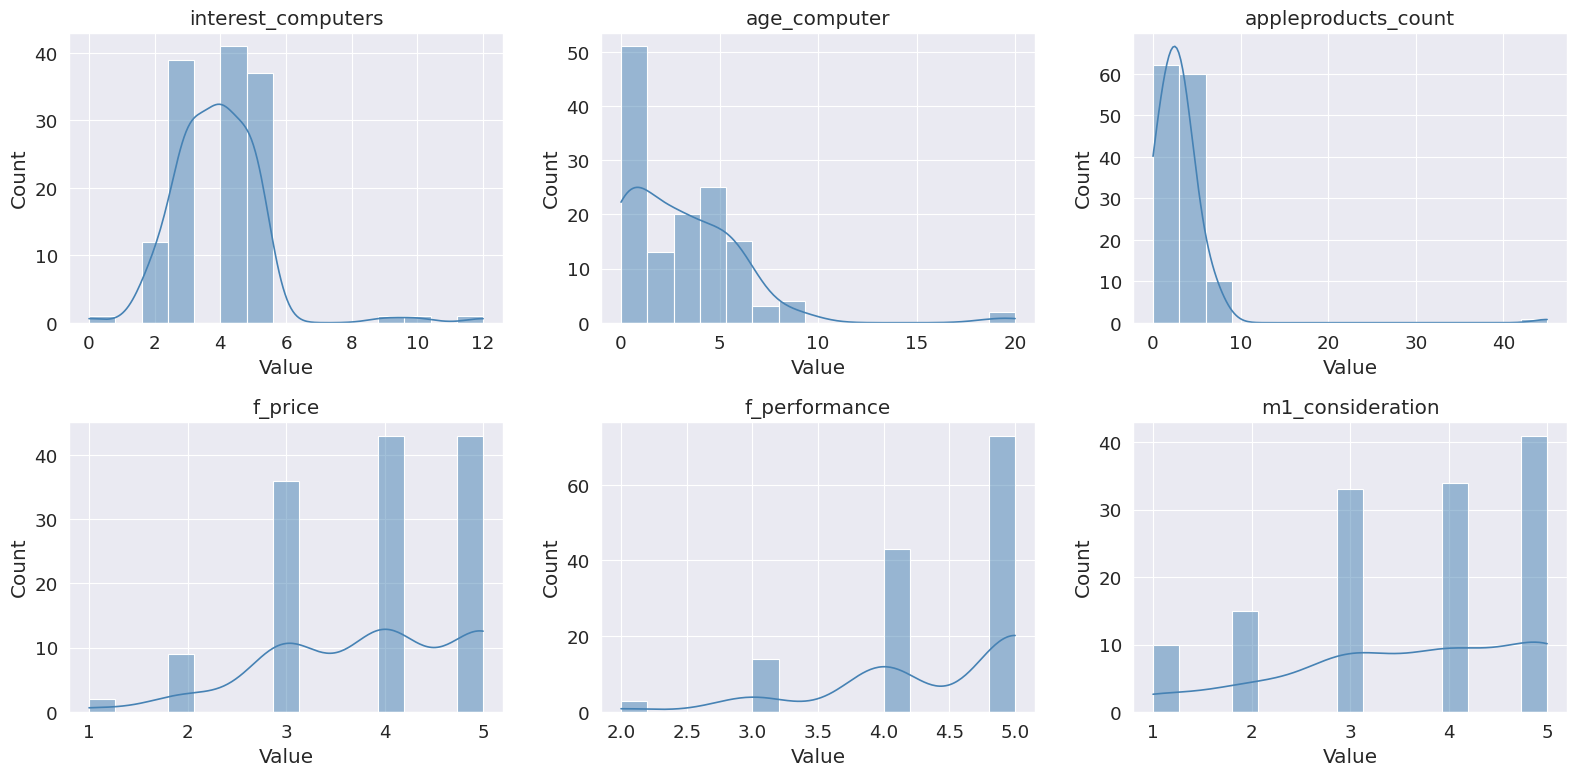

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

numeric_cols = ['interest_computers', 'age_computer', 'appleproducts_count', 
                'f_price', 'f_performance', 'm1_consideration']

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=15, color='steelblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('Value')
    
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

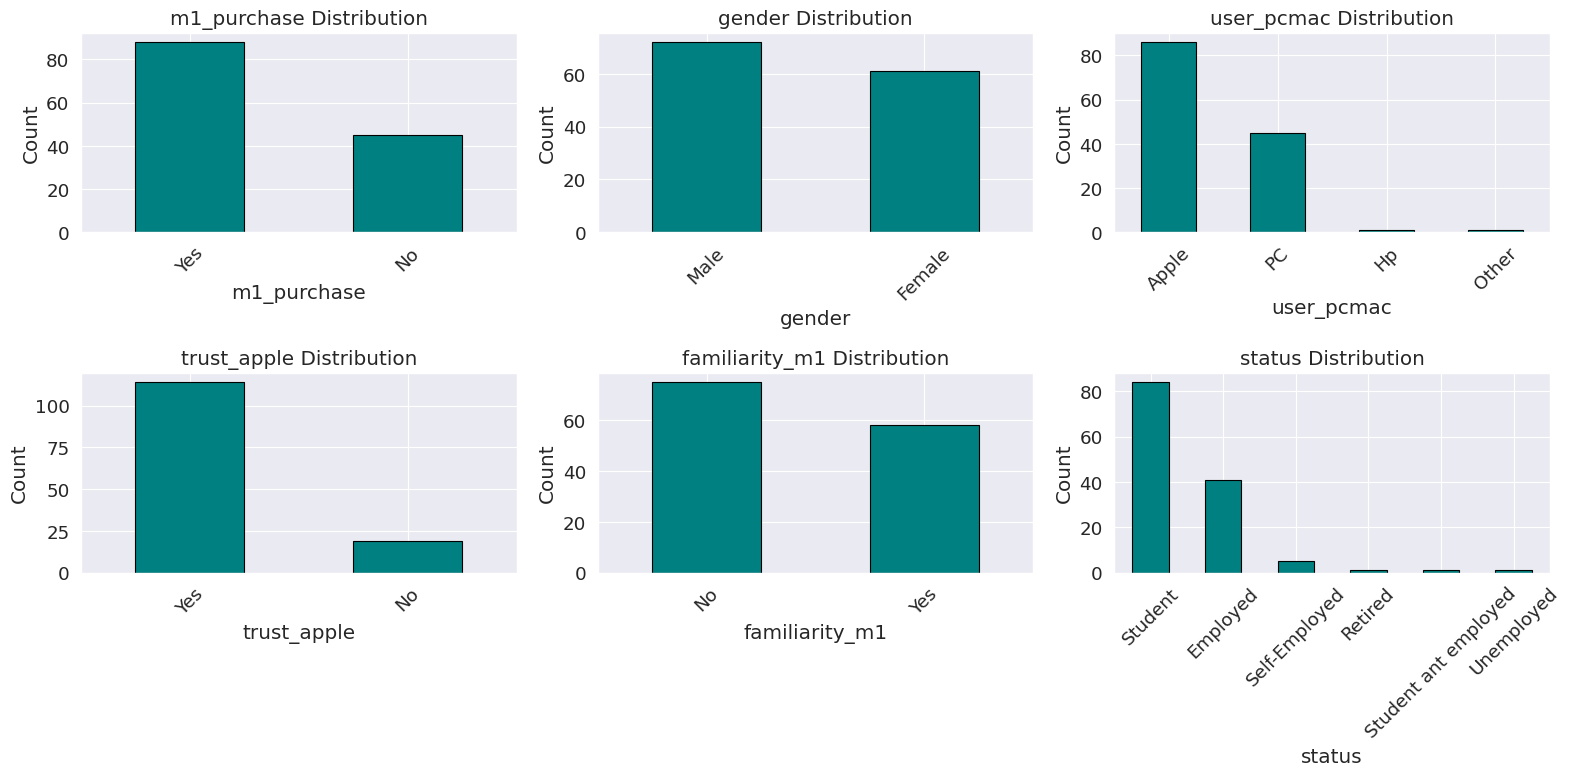

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

categorical_cols = ['m1_purchase', 'gender', 'user_pcmac', 'trust_apple', 'familiarity_m1', 'status']

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='teal', edgecolor='black')
    ax.set_title(f'{col} Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

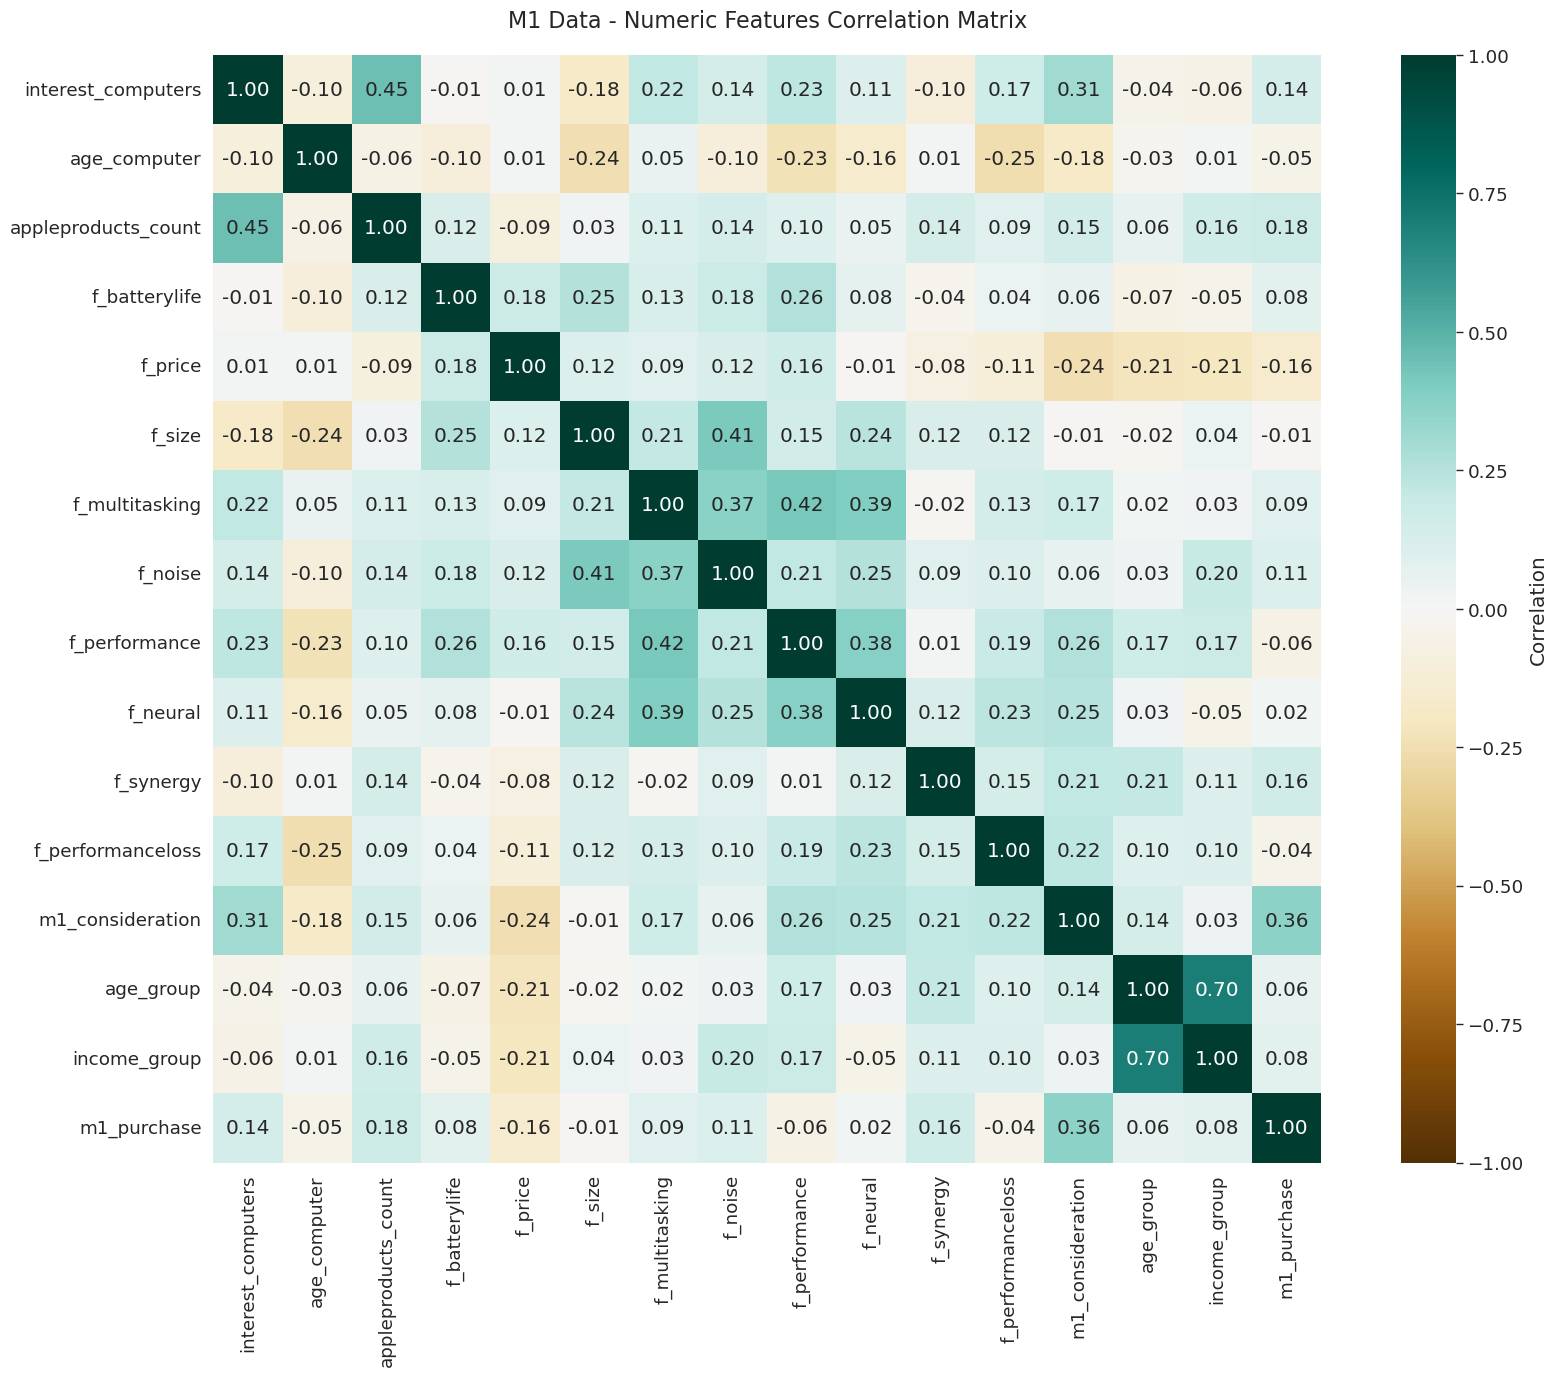

m1_purchase            1.000000
m1_consideration       0.364776
appleproducts_count    0.178095
f_synergy              0.162162
interest_computers     0.138464
f_noise                0.110478
f_multitasking         0.088213
income_group           0.084286
f_batterylife          0.081190
age_group              0.055838
f_neural               0.020152
f_size                -0.012233
f_performanceloss     -0.043691
age_computer          -0.052139
f_performance         -0.063705
f_price               -0.156249
Name: m1_purchase, dtype: float64

Top Correlations with m1_purchase:


In [8]:
numerics = df.select_dtypes(include='number').copy()

# Encode target variable for correlation analysis
df['m1_purchase_encoded'] = (df['m1_purchase'] == 'Yes').astype(int)
numerics['m1_purchase'] = df['m1_purchase_encoded']

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(numerics.corr(), annot=True, cmap='BrBG', fmt='.2f', 
            center=0, vmin=-1, vmax=1, square=True, ax=ax, 
            cbar_kws={'label': 'Correlation'})
ax.set_title('M1 Data - Numeric Features Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')

plt.show()
print(numerics.corr()['m1_purchase'].sort_values(ascending=False))

print('\nTop Correlations with m1_purchase:')

M1 Purchase Distribution:
m1_purchase
Yes    88
No     45
Name: count, dtype: int64

Percentage Distribution:
m1_purchase
Yes    66.17
No     33.83
Name: count, dtype: float64


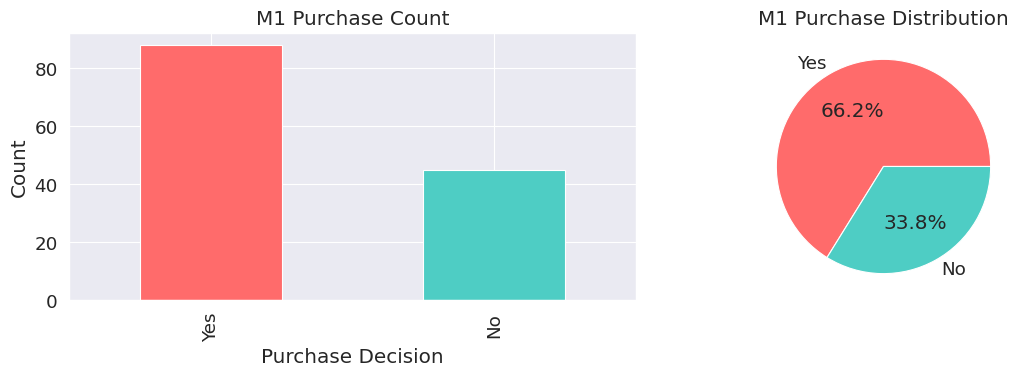

In [9]:
print('M1 Purchase Distribution:')
print(df['m1_purchase'].value_counts())
print('\nPercentage Distribution:')
print((df['m1_purchase'].value_counts() / len(df) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['m1_purchase'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('M1 Purchase Count')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Purchase Decision')

df['m1_purchase'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                       colors=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('M1 Purchase Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("=" * 70)
print("M1 DATASET - KEY INSIGHTS SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset Overview:")
print(f"   • Total Records: {df.shape[0]}")
print(f"   • Total Features: {df.shape[1]}")

print(f"\n🎯 Target Variable (m1_purchase):")
yes_count = (df['m1_purchase'] == 'Yes').sum()
no_count = (df['m1_purchase'] == 'No').sum()
print(f"   • Yes (Purchase): {yes_count} ({yes_count/len(df)*100:.1f}%)")
print(f"   • No (No Purchase): {no_count} ({no_count/len(df)*100:.1f}%)")

print(f"\n👥 Key Categorical Features:")
print(f"   • Gender: {df['gender'].unique()}")
print(f"   • Device Type: {df['user_pcmac'].unique()}")
print(f"   • Trust in Apple: {df['trust_apple'].unique()}")
print(f"   • M1 Familiarity: {df['familiarity_m1'].unique()}")
print(f"   • Employment Status: {df['status'].unique()}")

print(f"\n📈 Numeric Features Summary:")
for col in numerics.columns:
    print(f"   • {col}: Min={numerics[col].min():.2f}, Max={numerics[col].max():.2f}, Mean={numerics[col].mean():.2f}")

print(f"\n🔗 Top 5 Features Correlated with m1_purchase:")
top_corr = numerics.corr()['m1_purchase'].sort_values(ascending=False)[1:6]  # Exclude self-correlation
for feat, corr in top_corr.items():
    if feat != 'm1_purchase_encoded':
        print(f"   • {feat}: {corr:.4f}")

print("\n" + "=" * 70)

M1 DATASET - KEY INSIGHTS SUMMARY

📊 Dataset Overview:
   • Total Records: 133
   • Total Features: 23

🎯 Target Variable (m1_purchase):
   • Yes (Purchase): 88 (66.2%)
   • No (No Purchase): 45 (33.8%)

👥 Key Categorical Features:
   • Gender: ['Male' 'Female']
   • Device Type: ['PC' 'Apple' 'Hp' 'Other']
   • Trust in Apple: ['No' 'Yes']
   • M1 Familiarity: ['No' 'Yes']
   • Employment Status: ['Student' 'Employed' 'Retired' 'Student ant employed' 'Unemployed'
 'Self-Employed']

📈 Numeric Features Summary:
   • interest_computers: Min=0.00, Max=12.00, Mean=3.92
   • age_computer: Min=0.00, Max=20.00, Mean=3.04
   • appleproducts_count: Min=0.00, Max=45.00, Mean=2.89
   • f_batterylife: Min=1.00, Max=5.00, Mean=4.53
   • f_price: Min=1.00, Max=5.00, Mean=3.87
   • f_size: Min=1.00, Max=5.00, Mean=3.16
   • f_multitasking: Min=2.00, Max=5.00, Mean=4.12
   • f_noise: Min=1.00, Max=5.00, Mean=3.73
   • f_performance: Min=2.00, Max=5.00, Mean=4.40
   • f_neural: Min=1.00, Max=5.00, Mean

## 9. Key Insights Summary

## 8. Target Variable Analysis (M1 Purchase)

## 7. Correlation Analysis

## 6. Categorical Feature Distributions

## 5. Numeric Feature Distributions

## 4. Unique Values in Categorical Columns

## 3. Missing Values Check

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   trust_apple          133 non-null    object
 1   interest_computers   133 non-null    int64 
 2   age_computer         133 non-null    int64 
 3   user_pcmac           133 non-null    object
 4   appleproducts_count  133 non-null    int64 
 5   familiarity_m1       133 non-null    object
 6   f_batterylife        133 non-null    int64 
 7   f_price              133 non-null    int64 
 8   f_size               133 non-null    int64 
 9   f_multitasking       133 non-null    int64 
 10  f_noise              133 non-null    int64 
 11  f_performance        133 non-null    int64 
 12  f_neural             133 non-null    int64 
 13  f_synergy            133 non-null    int64 
 14  f_performanceloss    133 non-null    int64 
 15  m1_consideration     133 non-null    int64 
 16  m1_purch

## 2. Load and Inspect Dataset

## 1. Import Required Libraries